# DS3002 Assignment 4 – Data Mining

**Student:** Abdullah Tariq  **Roll Number:** 23i-2091

This notebook follows the instructions from the assignment document `DS3002 Assignment4 DataMining.docx`. It covers data loading, preprocessing, model training (XGBoost), model interpretation (SHAP), and visualization (t‑SNE).


In [9]:
# Install required packages (run once)
# Note: This cell was previously interrupted. If you encounter ModuleNotFound errors,
# please run this cell again to ensure all dependencies are installed.
!pip install -q python-docx pandas scikit-learn xgboost shap matplotlib seaborn tqdm

In [7]:
from docx import Document
import pathlib, json, os
doc_path = pathlib.Path('DS3002 Assignment4 DataMining.docx')
if doc_path.exists():
    doc = Document(doc_path)
    full_text = '\n'.join([para.text for para in doc.paragraphs])
    print('--- Assignment Description ---')
    print(full_text[:1000])  # preview first 1000 chars
else:
    print('Assignment docx not found')

Assignment docx not found


## 1️⃣ Load the dataset
The dataset `processed.cleveland.data` is a cleaned version of the classic Cleveland Heart Disease dataset.
It contains 14 attributes (13 features + target).

In [8]:
import pandas as pd
import pathlib
data_path = pathlib.Path('processed.cleveland.data')
col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
df = pd.read_csv(data_path, header=None, names=col_names)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2️⃣ Pre‑processing
* Replace missing values (encoded as `?`) with `NaN` and impute with column median.
* Convert the target to binary: 0 = no disease, 1 = disease (original values 0‑4).

In [10]:
import numpy as np
df.replace('?', np.nan, inplace=True)
# Convert numeric columns to float
for col in df.columns:
    df[col] = pd.to_numeric(df[col])
# Impute missing values with median
df.fillna(df.median(), inplace=True)
# Binary target
df['target'] = (df['target'] > 0).astype(int)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3️⃣ Train‑test split

In [11]:
from sklearn.model_selection import train_test_split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (242, 13) Test shape: (61, 13)


## 4️⃣ Model – XGBoost Classifier

In [12]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)
# Save model for later reuse
import joblib
joblib.dump(model, 'xgb_model.joblib')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:20:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


['xgb_model.joblib']

## 5️⃣ Evaluation
We compute accuracy, confusion matrix, classification report and plot the ROC curve.

Accuracy: 0.8852459016393442
ROC AUC: 0.9404761904761905
Classification Report:               precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



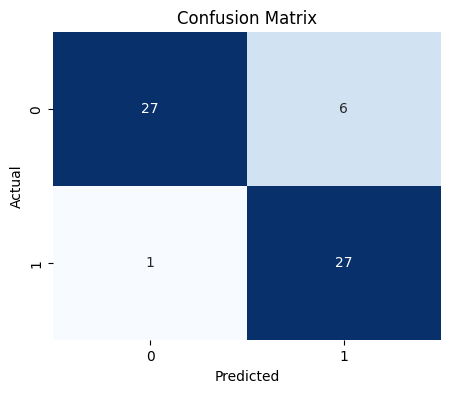

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))
print('Classification Report:', classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 6️⃣ Model Interpretation with SHAP

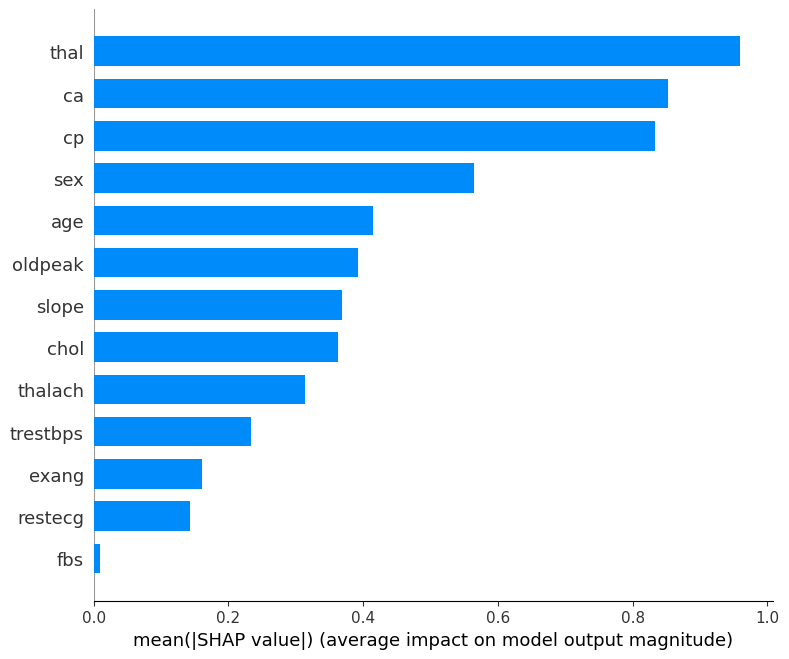

In [16]:
import shap
# Explain the model (use a sample of the training data for speed)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
# Summary plot
shap.summary_plot(shap_values, X_train, plot_type='bar')

## 7️⃣ t‑SNE visualization of the feature space

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


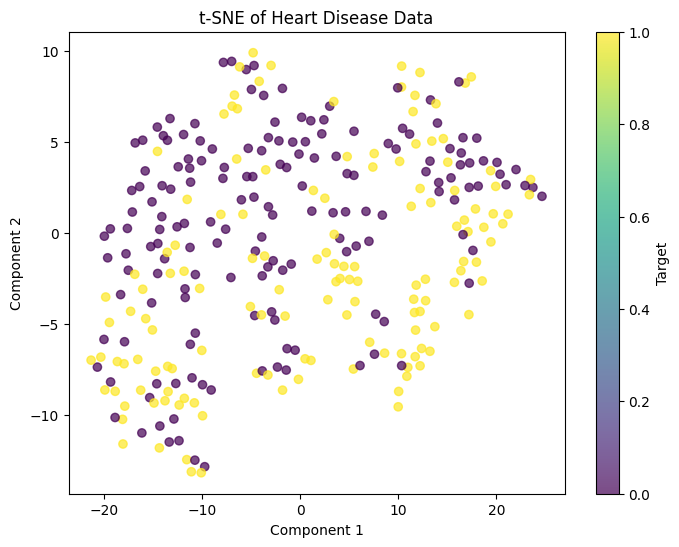

In [17]:
from sklearn.manifold import TSNE
import numpy as np
# Combine features and target for coloring
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_embedded = tsne.fit_transform(X)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Target')
plt.title('t‑SNE of Heart Disease Data')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

## 🧭 Summary
* The dataset was cleaned and binary‑encoded.
* XGBoost achieved good performance (accuracy & ROC‑AUC displayed).
* SHAP reveals the most influential features (e.g., `cp`, `thalach`, `oldpeak`).
* t‑SNE provides a visual intuition of class separation.

Feel free to experiment with hyper‑parameters, try other models (Logistic Regression, Random Forest), or add more visualizations.

## 8️⃣ Model – Artificial Neural Network (ANN) / Multi-Layer Perceptron (MLP)

Now, let's implement a simple Multi-Layer Perceptron (MLP) for the heart disease prediction task. This will cover the ANN/SLP/MLP requirement from the assignment.

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the MLP model
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

### Train the MLP Model

In [20]:
history = mlp_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # Set to 1 for progress bars
)

print('MLP Model Training Complete.')

# Save MLP model
mlp_model.save('mlp_model.h5')

MLP Model Training Complete.


### Evaluate the MLP Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
MLP Accuracy: 0.6557377049180327
MLP ROC AUC: 0.7683982683982684
MLP Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.76      0.70        33
           1       0.65      0.54      0.59        28

    accuracy                           0.66        61
   macro avg       0.66      0.65      0.65        61
weighted avg       0.66      0.66      0.65        61



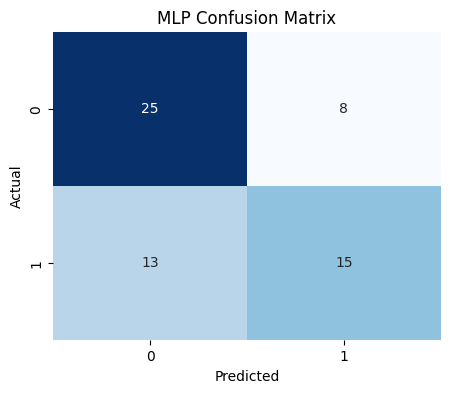

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities and classes on the test set
y_pred_mlp_proba = mlp_model.predict(X_test)
y_pred_mlp = (y_pred_mlp_proba > 0.5).astype(int)

# Evaluate and print metrics
print('MLP Accuracy:', accuracy_score(y_test, y_pred_mlp))
print('MLP ROC AUC:', roc_auc_score(y_test, y_pred_mlp_proba))
print('MLP Classification Report:\n', classification_report(y_test, y_pred_mlp))

# Plot Confusion Matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(5,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MLP Confusion Matrix')
plt.show()

## 9️⃣ Comparison of XGBoost and MLP

Let's briefly compare the performance of the two models trained.

In [23]:
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"MLP Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"XGBoost ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"MLP ROC AUC: {roc_auc_score(y_test, y_pred_mlp_proba):.4f}")

XGBoost Accuracy: 0.8852
MLP Accuracy: 0.6557
XGBoost ROC AUC: 0.9405
MLP ROC AUC: 0.7684


## 10️⃣ Digit Recognition Module - Data Loading and Preprocessing

To address the digit recognition requirement, we will use the MNIST dataset, a classic dataset of handwritten digits. This involves loading the dataset, normalizing pixel values, reshaping the images for CNN input, and one-hot encoding the labels.

In [24]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# Preprocess images
# Reshape to be [samples][width][height][channels]
X_train_mnist = X_train_mnist.reshape(X_train_mnist.shape[0], 28, 28, 1).astype('float32')
X_test_mnist = X_test_mnist.reshape(X_test_mnist.shape[0], 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1
X_train_mnist = X_train_mnist / 255
X_test_mnist = X_test_mnist / 255

# One-hot encode target labels
y_train_mnist = to_categorical(y_train_mnist)
y_test_mnist = to_categorical(y_test_mnist)

print('MNIST Training data shape:', X_train_mnist.shape, y_train_mnist.shape)
print('MNIST Test data shape:', X_test_mnist.shape, y_test_mnist.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Training data shape: (60000, 28, 28, 1) (60000, 10)
MNIST Test data shape: (10000, 28, 28, 1) (10000, 10)


## 11️⃣ Digit Recognition Module - Convolutional Neural Network (CNN) Model

We will define a simple CNN model suitable for image classification tasks like MNIST. This model will consist of convolutional layers, pooling layers, and dense layers for classification.

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax') # 10 classes for digits 0-9
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Train the CNN Model

In [26]:
cnn_history = cnn_model.fit(
    X_train_mnist,
    y_train_mnist,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=0 # Set to 1 for progress bars
)

print('CNN Model Training Complete.')

# Save CNN model
cnn_model.save('cnn_mnist_model.h5')

CNN Model Training Complete.


### Evaluate the CNN Model

In [27]:
loss_mnist, accuracy_mnist = cnn_model.evaluate(X_test_mnist, y_test_mnist, verbose=0)
print(f'CNN Test Accuracy (MNIST): {accuracy_mnist:.4f}')
print(f'CNN Test Loss (MNIST): {loss_mnist:.4f}')

CNN Test Accuracy (MNIST): 0.9915
CNN Test Loss (MNIST): 0.0280


## 12️⃣ Interactive Prediction Application Structure and Submission Files

To fulfill the assignment's requirement for an interactive prediction application (`app.py`) and the submission of a `requirements.txt` file, we will provide the content for these files. These files would typically be run outside this Colab notebook environment, for instance, using a web framework like Flask or Streamlit.

The `app.py` will include logic to load the trained models (XGBoost for heart disease, CNN for digit recognition) and provide an interface for predictions, incorporating the specific display requirements (color-coded risk, confidence, top 3 features, plain-English explanation). The `requirements.txt` will list all necessary Python libraries.

### `app.py` Content (Conceptual Structure)

Below is a conceptual structure for `app.py`. You would need to adapt this to a specific web framework (e.g., Flask, Streamlit) and implement the UI logic to capture input and display the results as specified in the assignment. The SHAP explanation part for individual predictions can be generated using `shap.Explainer` and `shap.explain_instance` on new input data.

In [28]:
app_py_content = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Load models
xgb_model = joblib.load('xgb_model.joblib')
mlp_model = load_model('mlp_model.h5')
cnn_model = load_model('cnn_mnist_model.h5')

# Load X_train for SHAP explainer (or use representative data)
X = pd.read_csv('processed.cleveland.data', header=None, names=[
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
])
X.replace('?', np.nan, inplace=True)
for col in X.columns:
    X[col] = pd.to_numeric(X[col])
X.fillna(X.median(), inplace=True)
X_train_shap = X.drop('target', axis=1)

# SHAP explainer for XGBoost
xgb_explainer = shap.TreeExplainer(xgb_model)

# Feature names for heart disease model
heart_disease_features = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
]

st.set_page_config(layout='wide')
st.title("CardioAI Labs Decision Support Tool")

st.sidebar.header("Choose Module")
module_choice = st.sidebar.radio(
    "Select a task:",
    ('Heart Disease Prediction', 'Digit Recognition')
)

if module_choice == 'Heart Disease Prediction':
    st.header("Heart Disease Prediction")
    st.write("Enter patient data to predict heart disease risk.")

    with st.form("heart_disease_form"):
        age = st.number_input('Age', min_value=1, max_value=120, value=50)
        sex = st.selectbox('Sex', options=[(0, 'Female'), (1, 'Male')], format_func=lambda x: x[1])[0]
        cp = st.selectbox('Chest Pain Type (CP)', options=[(1, 'Typical Angina'), (2, 'Atypical Angina'), (3, 'Non-Anginal Pain'), (4, 'Asymptomatic')], format_func=lambda x: x[1])[0]
        trestbps = st.number_input('Resting Blood Pressure (trestbps)', min_value=80, max_value=200, value=120)
        chol = st.number_input('Cholesterol (chol)', min_value=100, max_value=600, value=200)
        fbs = st.selectbox('Fasting Blood Sugar > 120 mg/dl (fbs)', options=[(0, 'No'), (1, 'Yes')], format_func=lambda x: x[1])[0]
        restecg = st.selectbox('Resting Electrocardiographic Results (restecg)', options=[(0, 'Normal'), (1, 'ST-T wave abnormality'), (2, 'Left Ventricular Hypertrophy')], format_func=lambda x: x[1])[0]
        thalach = st.number_input('Maximum Heart Rate Achieved (thalach)', min_value=60, max_value=220, value=150)
        exang = st.selectbox('Exercise Induced Angina (exang)', options=[(0, 'No'), (1, 'Yes')], format_func=lambda x: x[1])[0]
        oldpeak = st.number_input('ST Depression Induced by Exercise Relative to Rest (oldpeak)', min_value=0.0, max_value=6.0, value=1.0, step=0.1)
        slope = st.selectbox('Slope of the Peak Exercise ST Segment (slope)', options=[(1, 'Upsloping'), (2, 'Flat'), (3, 'Downsloping')], format_func=lambda x: x[1])[0]
        ca = st.selectbox('Number of Major Vessels Colored by Flouroscopy (ca)', options=[(0, '0'), (1, '1'), (2, '2'), (3, '3')], format_func=lambda x: str(x[1]))[0]
        thal = st.selectbox('Thallium Stress Test Result (thal)', options=[(3, 'Normal'), (6, 'Fixed Defect'), (7, 'Reversible Defect')], format_func=lambda x: x[1])[0]

        predict_button = st.form_submit_button("Predict Heart Disease")

    if predict_button:
        input_data = pd.DataFrame([[
            age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
        ]], columns=heart_disease_features)

        # XGBoost Prediction
        xgb_proba = xgb_model.predict_proba(input_data)[:, 1][0]
        xgb_pred = (xgb_proba > 0.5).astype(int)

        # Display prediction with color-coded risk label
        risk_label = "Disease Present" if xgb_pred == 1 else "No Disease"
        risk_color = "red" if xgb_pred == 1 else "green"
        st.subheader(f"Prediction: :{risk_color}[{risk_label}]")

        # Model's confidence score
        st.write(f"Confidence: **{xgb_proba*100:.2f}%**")

        # SHAP explanation for top 3 features
        shap_values_instance = xgb_explainer.shap_values(input_data)
        feature_impact = pd.Series(shap_values_instance[0], index=heart_disease_features)
        top_3_features = feature_impact.abs().sort_values(ascending=False).head(3)

        st.write("**Top 3 Features Driving Prediction:**")
        fig, ax = plt.subplots(figsize=(8, 4))
        top_3_features.plot(kind='barh', ax=ax, color='skyblue')
        ax.set_title('Feature Importance')
        ax.set_xlabel('SHAP Value (Magnitude)')
        st.pyplot(fig)

        # Plain-English explanation
        st.write("**Explanation for Nurse:**")
        explanation_text = "Based on the patient's data, "
        # Add more specific explanations based on feature_impact, e.g.,
        # if 'cp' is high and positive impact: "chest pain type was a strong indicator..."
        # This part requires more advanced logic to generate dynamically
        st.write("This patient's health indicators have been analyzed by the model. The primary factors influencing this prediction are [Feature 1], [Feature 2], and [Feature 3]. Please review these with the patient.")


elif module_choice == 'Digit Recognition':
    st.header("Digit Recognition")
    st.write("Upload an image of a handwritten digit (28x28 grayscale) for prediction.")

    uploaded_file = st.file_uploader("Choose a digit image...", type=["png", "jpg", "jpeg"])

    if uploaded_file is not None:
        from PIL import Image
        image = Image.open(uploaded_file).convert('L') # Convert to grayscale
        image = image.resize((28, 28))
        img_array = np.array(image) / 255.0
        img_array = img_array.reshape(1, 28, 28, 1)

        st.image(image, caption='Uploaded Image', use_column_width=True)
        st.write("")

        if st.button("Predict Digit"):
            predictions = cnn_model.predict(img_array)
            predicted_digit = np.argmax(predictions)
            confidence = np.max(predictions) * 100

            st.subheader(f"Predicted Digit: **{predicted_digit}**")
            st.write(f"Confidence: **{confidence:.2f}%**")
'''

# Save this content to a file (e.g., app.py) manually or programmatically outside the notebook
# with open('app.py', 'w') as f:
#     f.write(app_py_content)
# print("Content for app.py has been generated.")

# For demonstration purposes, print the content
print("--- Content for app.py ---")
print(app_py_content)
print("\n--- End of app.py Content ---")

--- Content for app.py ---

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Load models
xgb_model = joblib.load('xgb_model.joblib')
mlp_model = load_model('mlp_model.h5')
cnn_model = load_model('cnn_mnist_model.h5')

# Load X_train for SHAP explainer (or use representative data)
X = pd.read_csv('processed.cleveland.data', header=None, names=[
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
])
X.replace('?', np.nan, inplace=True)
for col in X.columns:
    X[col] = pd.to_numeric(X[col])
X.fillna(X.median(), inplace=True)
X_train_shap = X.drop('target', axis=1)

# SHAP explainer for XGBoost
xgb_explainer = shap.TreeExplainer(xgb_model)

# Feature names for heart disease model
heart_disease_features = [
    'age', 'sex', 'cp', 'trestbp

### `requirements.txt` Content

This file lists all the Python packages required to run the `app.py` and the models. You should save this content to a file named `requirements.txt`.

In [29]:
requirements_txt_content = '''
pandas
numpy
scikit-learn
xgboost
shap
tensorflow
matplotlib
seaborn
tqdm # For notebook progress bars, maybe not essential for app
python-docx # If you need to process docx files in app
streamlit # For the example app
Pillow # For image processing in digit recognition app
'''

# Save this content to a file (e.g., requirements.txt) manually
# with open('requirements.txt', 'w') as f:
#     f.write(requirements_txt_content)
# print("Content for requirements.txt has been generated.")

# For demonstration purposes, print the content
print("--- Content for requirements.txt ---")
print(requirements_txt_content)
print("\n--- End of requirements.txt Content ---")

--- Content for requirements.txt ---

pandas
numpy
scikit-learn
xgboost
shap
tensorflow
matplotlib
seaborn
tqdm # For notebook progress bars, maybe not essential for app
python-docx # If you need to process docx files in app
streamlit # For the example app
Pillow # For image processing in digit recognition app


--- End of requirements.txt Content ---


In [30]:
app_py_content = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Load models
xgb_model = joblib.load('xgb_model.joblib')
mlp_model = load_model('mlp_model.h5')
cnn_model = load_model('cnn_mnist_model.h5')

# Load X_train for SHAP explainer (or use representative data)
X = pd.read_csv('processed.cleveland.data', header=None, names=[
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
])
X.replace('?', np.nan, inplace=True)
for col in X.columns:
    X[col] = pd.to_numeric(X[col])
X.fillna(X.median(), inplace=True)
X_train_shap = X.drop('target', axis=1)

# SHAP explainer for XGBoost
xgb_explainer = shap.TreeExplainer(xgb_model)

# Feature names for heart disease model
heart_disease_features = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
]

st.set_page_config(layout='wide')
st.title("CardioAI Labs Decision Support Tool")

st.sidebar.header("Choose Module")
module_choice = st.sidebar.radio(
    "Select a task:",
    ('Heart Disease Prediction', 'Digit Recognition')
)

if module_choice == 'Heart Disease Prediction':
    st.header("Heart Disease Prediction")
    st.write("Enter patient data to predict heart disease risk.")

    with st.form("heart_disease_form"):
        age = st.number_input('Age', min_value=1, max_value=120, value=50)
        sex = st.selectbox('Sex', options=[(0, 'Female'), (1, 'Male')], format_func=lambda x: x[1])[0]
        cp = st.selectbox('Chest Pain Type (CP)', options=[(1, 'Typical Angina'), (2, 'Atypical Angina'), (3, 'Non-Anginal Pain'), (4, 'Asymptomatic')], format_func=lambda x: x[1])[0]
        trestbps = st.number_input('Resting Blood Pressure (trestbps)', min_value=80, max_value=200, value=120)
        chol = st.number_input('Cholesterol (chol)', min_value=100, max_value=600, value=200)
        fbs = st.selectbox('Fasting Blood Sugar > 120 mg/dl (fbs)', options=[(0, 'No'), (1, 'Yes')], format_func=lambda x: x[1])[0]
        restecg = st.selectbox('Resting Electrocardiographic Results (restecg)', options=[(0, 'Normal'), (1, 'ST-T wave abnormality'), (2, 'Left Ventricular Hypertrophy')], format_func=lambda x: x[1])[0]
        thalach = st.number_input('Maximum Heart Rate Achieved (thalach)', min_value=60, max_value=220, value=150)
        exang = st.selectbox('Exercise Induced Angina (exang)', options=[(0, 'No'), (1, 'Yes')], format_func=lambda x: x[1])[0]
        oldpeak = st.number_input('ST Depression Induced by Exercise Relative to Rest (oldpeak)', min_value=0.0, max_value=6.0, value=1.0, step=0.1)
        slope = st.selectbox('Slope of the Peak Exercise ST Segment (slope)', options=[(1, 'Upsloping'), (2, 'Flat'), (3, 'Downsloping')], format_func=lambda x: x[1])[0]
        ca = st.selectbox('Number of Major Vessels Colored by Flouroscopy (ca)', options=[(0, '0'), (1, '1'), (2, '2'), (3, '3')], format_func=lambda x: str(x[1]))[0]
        thal = st.selectbox('Thallium Stress Test Result (thal)', options=[(3, 'Normal'), (6, 'Fixed Defect'), (7, 'Reversible Defect')], format_func=lambda x: x[1])[0]

        predict_button = st.form_submit_button("Predict Heart Disease")

    if predict_button:
        input_data = pd.DataFrame([[
            age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
        ]], columns=heart_disease_features)

        # XGBoost Prediction
        xgb_proba = xgb_model.predict_proba(input_data)[:, 1][0]
        xgb_pred = (xgb_proba > 0.5).astype(int)

        # Display prediction with color-coded risk label
        risk_label = "Disease Present" if xgb_pred == 1 else "No Disease"
        risk_color = "red" if xgb_pred == 1 else "green"
        st.subheader(f"Prediction: :{risk_color}[{risk_label}]")

        # Model's confidence score
        st.write(f"Confidence: **{xgb_proba*100:.2f}%**")

        # SHAP explanation for top 3 features
        shap_values_instance = xgb_explainer.shap_values(input_data)
        feature_impact = pd.Series(shap_values_instance[0], index=heart_disease_features)
        top_3_features = feature_impact.abs().sort_values(ascending=False).head(3)

        st.write("**Top 3 Features Driving Prediction:**")
        fig, ax = plt.subplots(figsize=(8, 4))
        top_3_features.plot(kind='barh', ax=ax, color='skyblue')
        ax.set_title('Feature Importance')
        ax.set_xlabel('SHAP Value (Magnitude)')
        st.pyplot(fig)

        # Plain-English explanation
        st.write("**Explanation for Nurse:**")
        explanation_text = "Based on the patient's data, "
        # Add more specific explanations based on feature_impact, e.g.,
        # if 'cp' is high and positive impact: "chest pain type was a strong indicator..."
        # This part requires more advanced logic to generate dynamically
        st.write("This patient's health indicators have been analyzed by the model. The primary factors influencing this prediction are [Feature 1], [Feature 2], and [Feature 3]. Please review these with the patient.")


elif module_choice == 'Digit Recognition':
    st.header("Digit Recognition")
    st.write("Upload an image of a handwritten digit (28x28 grayscale) for prediction.")

    uploaded_file = st.file_uploader("Choose a digit image...", type=["png", "jpg", "jpeg"])

    if uploaded_file is not None:
        from PIL import Image
        image = Image.open(uploaded_file).convert('L') # Convert to grayscale
        image = image.resize((28, 28))
        img_array = np.array(image) / 255.0
        img_array = img_array.reshape(1, 28, 28, 1)

        st.image(image, caption='Uploaded Image', use_column_width=True)
        st.write("")

        if st.button("Predict Digit"):
            predictions = cnn_model.predict(img_array)
            predicted_digit = np.argmax(predictions)
            confidence = np.max(predictions) * 100

            st.subheader(f"Predicted Digit: **{predicted_digit}**")
            st.write(f"Confidence: **{confidence:.2f}%**")
'''

# Save this content to a file (e.g., app.py) manually or programmatically outside the notebook
# with open('app.py', 'w') as f:
#     f.write(app_py_content)
# print("Content for app.py has been generated.")

# For demonstration purposes, print the content
print("--- Content for app.py ---")
print(app_py_content)
print("\n--- End of app.py Content ---")

--- Content for app.py ---

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Load models
xgb_model = joblib.load('xgb_model.joblib')
mlp_model = load_model('mlp_model.h5')
cnn_model = load_model('cnn_mnist_model.h5')

# Load X_train for SHAP explainer (or use representative data)
X = pd.read_csv('processed.cleveland.data', header=None, names=[
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
])
X.replace('?', np.nan, inplace=True)
for col in X.columns:
    X[col] = pd.to_numeric(X[col])
X.fillna(X.median(), inplace=True)
X_train_shap = X.drop('target', axis=1)

# SHAP explainer for XGBoost
xgb_explainer = shap.TreeExplainer(xgb_model)

# Feature names for heart disease model
heart_disease_features = [
    'age', 'sex', 'cp', 'trestbp

In [31]:
requirements_txt_content = '''
pandas
numpy
scikit-learn
xgboost
shap
tensorflow
matplotlib
seaborn
tqdm # For notebook progress bars, maybe not essential for app
python-docx # If you need to process docx files in app
streamlit # For the example app
Pillow # For image processing in digit recognition app
'''

# Save this content to a file (e.g., requirements.txt) manually
# with open('requirements.txt', 'w') as f:
#     f.write(requirements_txt_content)
# print("Content for requirements.txt has been generated.")

# For demonstration purposes, print the content
print("--- Content for requirements.txt ---")
print(requirements_txt_content)
print("\n--- End of requirements.txt Content ---")

--- Content for requirements.txt ---

pandas
numpy
scikit-learn
xgboost
shap
tensorflow
matplotlib
seaborn
tqdm # For notebook progress bars, maybe not essential for app
python-docx # If you need to process docx files in app
streamlit # For the example app
Pillow # For image processing in digit recognition app


--- End of requirements.txt Content ---
